In [1]:
import os 
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
import h5py
import numpy as np 


from scipy.integrate import simps
from scipy.optimize import curve_fit
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.lines import Line2D

from euphonic import Quantity,ForceConstants,ureg
from euphonic.plot import plot_1d

sns.set_context("talk")

%matplotlib inline

In [2]:


# Fit the resolution data to a polynomial for extrapolation
def poly_func(x, a, b, c):
    return a * x**2 + b * x + c

# Create a function to get resolution for any energy
def get_resolution(e,popt):
    return np.maximum(poly_func(e, *popt), 1e-10)  # Ensure non-zero resolution


# Perform Gaussian broadening using convolution with energy-dependent widths
def gaussian_broadening(dos, energy, sigmas):
    broadened_dos = np.zeros_like(dos)
    for i in range(len(energy)):
        # Create a Gaussian kernel centered at each energy point with width sigmas[i]
        kernel = np.exp(-0.5 * ((energy - energy[i]) / sigmas[i])**2)
        kernel /= simps(kernel, energy)  # Normalize the kernel to preserve area
        broadened_dos += dos[i] * kernel  # Convolve DOS with Gaussian kernel
    return broadened_dos

def apply_gaussian_broadening(dos_data,metric='dos total (nm2/ps)',unit_cell_atoms=1):
    energy = dos_data['Energy Transfer (meV)'].values
    dos = dos_data[metric].values

    resolution_data = pd.read_csv('../data/resolution.csv')
    res_energy = resolution_data['Energy (meV)'].values
    resolution = resolution_data['Resolution'].values
    popt, _ = curve_fit(poly_func, res_energy, resolution)
    
    # Create an array of sigmas for Gaussian broadening based on the resolution function
    sigmas = get_resolution(energy,popt) / np.sqrt(8 * np.log(2))  # Convert FWHM to sigma


    broadened_dos = gaussian_broadening(dos, energy, sigmas)

    # Area normalize both original and broadened DOS
    original_area = simps(dos, energy)
    broadened_area = simps(broadened_dos, energy)

    dos_normalized = dos / original_area
    broadened_dos_normalized = broadened_dos / broadened_area
    return 3*unit_cell_atoms*broadened_dos_normalized

Force constants not found in ../results/qe/fdm/results/phonopy.yaml, attempting to read from ../results/qe/fdm/results/FORCE_CONSTANTS


/tmp/ipykernel_233/871495719.py:38: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data_dict["S(E)"]=data_dict["Max Normalized Count"]/(np.array(data_dict["Energy Transfer (meV)"])+np.finfo(float).eps)
/home/galavizp/.local/lib/python3.8/site-packages/pandas/core/construction.py:616: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.array(data, copy=copy)
/tmp/ipykernel_233/871495719.py:38: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data_dict["S(E)"]=data_dict["Max Normalized Count"]/(np.array(data_dict["Energy Transfer (meV)"])+np.finfo(float).eps)
/home/galavizp/.local/lib/python3.8/site-packages/pandas/core/construction.py:616: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.array(data, copy=copy)


,Energy Transfer (meV),Max Normalized Count,O,Si,S(E),Method,Weight,Software
0,1.0,0.038813,0.031382,0.028663,0.778329,DFT,Incoherent,QE
1,1.1,0.040818,0.033168,0.030075,0.744125,DFT,Incoherent,QE
2,1.2,0.042892,0.035034,0.031528,0.716775,DFT,Incoherent,QE
3,1.3,0.045036,0.036984,0.033021,0.694703,DFT,Incoherent,QE
4,1.4,0.047252,0.039023,0.034555,0.676833,DFT,Incoherent,QE
...,...,...,...,...,...,...,...,...
3973,199.4,0.000000,0.000000,0.000000,0.000000,DFT,Coherent,QE
3974,199.5,0.000000,0.000000,0.000000,0.000000,DFT,Coherent,QE
3975,199.6,0.000000,0.000000,0.000000,0.000000,DFT,Coherent,QE
3976,199.7,0.000000,0.000000,0.000000,0.000000,DFT,Coherent,QE


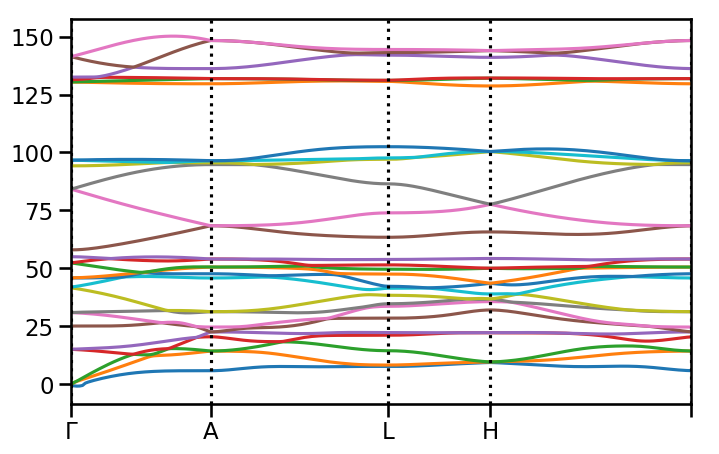

In [3]:
fc = ForceConstants.from_phonopy(path='../results/qe/fdm/results/',
                                 summary_name='phonopy.yaml')
cell = fc.crystal.to_spglib_cell()
qpts = pd.read_csv("../data/kpoints.csv")[["x","y","z"]].values
data_list=list()
for i, (start,end) in enumerate(zip(qpts[:-1],qpts[1:])):
        data_list+=list(np.linspace(start,end))
        
df_qpoints=pd.DataFrame(data_list).drop_duplicates()

# Calculate frequencies/eigenvectors
phonons = fc.calculate_qpoint_phonon_modes(df_qpoints.values, asr='reciprocal')


bands = phonons.get_dispersion()  # type: Spectrum1DCollection
# Create an array of energy bins 0 - 20 in meV
fig = plot_1d(bands)
fig.set_size_inches(8,5)
ax1,ax2=fig.get_axes()
xtics=ax1.get_xticks()
xticklabels=ax1.get_xticklabels()
n=[ax1.axvline(xx,c="black",ls="dotted") for xx in xtics]

energy_bins = np.arange(1, 200, 0.1)*ureg('meV')
# Calculate dos
broaden=5
df_list=list()
for weight in ['incoherent','coherent']:
    pdos = phonons.calculate_pdos(energy_bins, weighting=weight)  # atom resolved pdos
    species_pdos = pdos.group_by('species')  # species resolved pdos
    broadened_species_spectrum=species_pdos.broaden(broaden*ureg('meV'))
    total_dos = pdos.sum()  # total dos
    broadened_spectrum=total_dos.broaden(broaden*ureg('meV'))
    data_dict={"Energy Transfer (meV)":broadened_species_spectrum.x_data[:-1]
                ,"Max Normalized Count":broadened_spectrum.y_data/np.max(broadened_spectrum.y_data) }
    for i,item in enumerate(species_pdos.metadata['line_data']):
        data_dict[item['species']]=broadened_species_spectrum.y_data[i]/np.max(broadened_species_spectrum.y_data[i])
    data_dict["S(E)"]=data_dict["Max Normalized Count"]/(np.array(data_dict["Energy Transfer (meV)"])+np.finfo(float).eps)
    data_dict["S(E)"]=data_dict["S(E)"]/data_dict["S(E)"].max()
    data_dict["Method"]="DFT"
    data_dict["Weight"]=weight.capitalize()
    df_list.append(pd.DataFrame(data_dict))
df_dos_dft_qe=pd.concat(df_list,ignore_index=True)
df_dos_dft_qe["Software"]="QE"
display(df_dos_dft_qe)

Force constants not found in ../results/vasp/fdm/results/phonopy.yaml, attempting to read from ../results/vasp/fdm/results/FORCE_CONSTANTS


/tmp/ipykernel_233/2094933992.py:38: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data_dict["S(E)"]=data_dict["Max Normalized Count"]/(np.array(data_dict["Energy Transfer (meV)"])+np.finfo(float).eps)
/home/galavizp/.local/lib/python3.8/site-packages/pandas/core/construction.py:616: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.array(data, copy=copy)
/tmp/ipykernel_233/2094933992.py:38: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data_dict["S(E)"]=data_dict["Max Normalized Count"]/(np.array(data_dict["Energy Transfer (meV)"])+np.finfo(float).eps)
/home/galavizp/.local/lib/python3.8/site-packages/pandas/core/construction.py:616: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.array(data, copy=copy)


,Energy Transfer (meV),Max Normalized Count,O,Si,S(E),Method,Weight,Software,Energy Transfer (cm$^{-1}$)
0,1.0,0.038813,0.031382,0.028663,0.778329,DFT,Incoherent,QE,8.065610
1,1.1,0.040818,0.033168,0.030075,0.744125,DFT,Incoherent,QE,8.872171
2,1.2,0.042892,0.035034,0.031528,0.716775,DFT,Incoherent,QE,9.678732
3,1.3,0.045036,0.036984,0.033021,0.694703,DFT,Incoherent,QE,10.485293
4,1.4,0.047252,0.039023,0.034555,0.676833,DFT,Incoherent,QE,11.291854
...,...,...,...,...,...,...,...,...,...
3973,199.4,0.000000,0.000000,0.000000,0.000000,DFT,Coherent,VASP,1608.282634
3974,199.5,0.000000,0.000000,0.000000,0.000000,DFT,Coherent,VASP,1609.089195
3975,199.6,0.000000,0.000000,0.000000,0.000000,DFT,Coherent,VASP,1609.895756
3976,199.7,0.000000,0.000000,0.000000,0.000000,DFT,Coherent,VASP,1610.702317


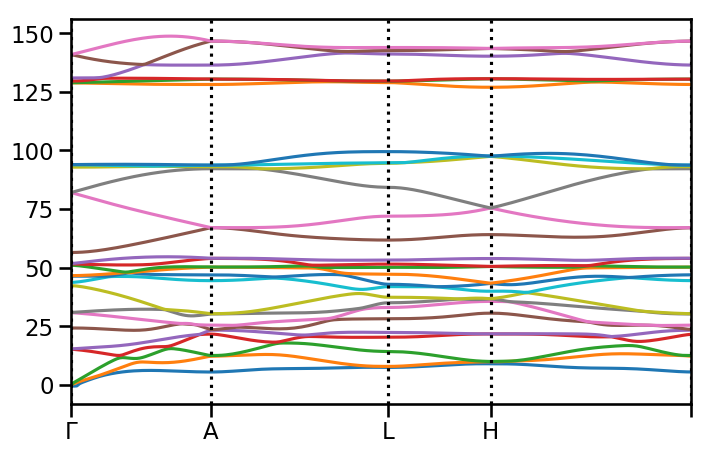

In [4]:
fc = ForceConstants.from_phonopy(path='../results/vasp/fdm/results/',
                                 summary_name='phonopy.yaml')
cell = fc.crystal.to_spglib_cell()
qpts = pd.read_csv("../data/kpoints.csv")[["x","y","z"]].values
data_list=list()
for i, (start,end) in enumerate(zip(qpts[:-1],qpts[1:])):
        data_list+=list(np.linspace(start,end))
        
df_qpoints=pd.DataFrame(data_list).drop_duplicates()

# Calculate frequencies/eigenvectors
phonons = fc.calculate_qpoint_phonon_modes(df_qpoints.values, asr='reciprocal')


bands = phonons.get_dispersion()  # type: Spectrum1DCollection
# Create an array of energy bins 0 - 20 in meV
fig = plot_1d(bands)
fig.set_size_inches(8,5)
ax1,ax2=fig.get_axes()
xtics=ax1.get_xticks()
xticklabels=ax1.get_xticklabels()
n=[ax1.axvline(xx,c="black",ls="dotted") for xx in xtics]

energy_bins = np.arange(1, 200, 0.1)*ureg('meV')
# Calculate dos
broaden=5
df_list=list()
for weight in ['incoherent','coherent']:
    pdos = phonons.calculate_pdos(energy_bins, weighting=weight)  # atom resolved pdos
    species_pdos = pdos.group_by('species')  # species resolved pdos
    broadened_species_spectrum=species_pdos.broaden(broaden*ureg('meV'))
    total_dos = pdos.sum()  # total dos
    broadened_spectrum=total_dos.broaden(broaden*ureg('meV'))
    data_dict={"Energy Transfer (meV)":broadened_species_spectrum.x_data[:-1]
                ,"Max Normalized Count":broadened_spectrum.y_data/np.max(broadened_spectrum.y_data) }
    for i,item in enumerate(species_pdos.metadata['line_data']):
        data_dict[item['species']]=broadened_species_spectrum.y_data[i]/np.max(broadened_species_spectrum.y_data[i])
    data_dict["S(E)"]=data_dict["Max Normalized Count"]/(np.array(data_dict["Energy Transfer (meV)"])+np.finfo(float).eps)
    data_dict["S(E)"]=data_dict["S(E)"]/data_dict["S(E)"].max()
    data_dict["Method"]="DFT"
    data_dict["Weight"]=weight.capitalize()
    df_list.append(pd.DataFrame(data_dict))
df_dos_dft_vasp=pd.concat(df_list,ignore_index=True)
df_dos_dft_vasp["Software"]="VASP"
df_dos_dft=pd.concat([df_dos_dft_qe,df_dos_dft_vasp])

df_dos_dft["Energy Transfer (cm$^{-1}$)"]=df_dos_dft["Energy Transfer (meV)"]*8.065610

display(df_dos_dft)

In [5]:
results_directory={"../results/gromacs/bulk/alpha_quartz/result/md_prod_100/":("PoreMS",100)
                   ,"../results/gromacs/bulk/alpha_quartz/result/md_prod_200/":("PoreMS",200)
                   ,"../results/gromacs/bulk/alpha_quartz/result/md_prod_300/":("PoreMS",300)
                   
                  }
df_list=list()

min_energy=1
max_energy=200

for data_directory,(force_field,temperature) in results_directory.items():
    for filename in os.listdir(data_directory):
        if not "dos.h5" in filename:
            continue
        print(os.path.join(data_directory,filename))
        h5file=h5py.File(os.path.join(data_directory,filename))
        data_dict=dict()
        omega_shape=h5file["omega"][:].shape
        for k in h5file.keys():
            data_array=h5file[k][:]
            if data_array.shape != omega_shape or "_0" in k:
                continue
            units=h5file[k].attrs['units']
            data_dict["%s (%s)"%(k.replace("_"," "),units)]=data_array
        df_tmp=pd.DataFrame(data_dict).query("%f < `omega (rad/ps)` and `omega (rad/ps)` < %f"%(min_energy/0.6582,max_energy/0.6582))
        directory_split=data_directory.split("/")
        system=directory_split[3]
        df_tmp["Weight"]=" ".join(filename.split("_")[:-1]).replace('b ','').capitalize()
        df_tmp["Method"]="MD"
        df_tmp["Force Field"]=force_field
        df_tmp["Energy Transfer (meV)"]=df_tmp["omega (rad/ps)"]*0.6582
        df_tmp["Normalized Count"]=apply_gaussian_broadening(df_tmp)
        for species in ["Si","O"]:
            df_tmp[species]=apply_gaussian_broadening(df_tmp,"dos %s (nm2/ps)"%species)
            df_tmp[species]/=df_tmp[species].max()
        df_tmp["Max Normalized Count"]=df_tmp["Normalized Count"]/df_tmp["Normalized Count"].max()
        df_tmp["S(E)"]=df_tmp["Max Normalized Count"]/(df_tmp["Energy Transfer (meV)"]+np.finfo(float).eps)
        df_tmp["S(E)"]=df_tmp["S(E)"]/df_tmp["S(E)"].max()
                
        df_tmp["Temperature (K)"]=temperature
        df_tmp["Software"]=directory_split[2]
        df_tmp["System"]=system #.split("_")[0].replace("nanoparticle", "np")
        
        df_list.append(df_tmp)
        
df_dos_gromacs=pd.concat(df_list,ignore_index=True)

../results/gromacs/bulk/alpha_quartz/result/md_prod_100/b_coherent_dos.h5
../results/gromacs/bulk/alpha_quartz/result/md_prod_100/b_incoherent_dos.h5
../results/gromacs/bulk/alpha_quartz/result/md_prod_200/b_coherent_dos.h5
../results/gromacs/bulk/alpha_quartz/result/md_prod_200/b_incoherent_dos.h5
../results/gromacs/bulk/alpha_quartz/result/md_prod_300/b_coherent_dos.h5
../results/gromacs/bulk/alpha_quartz/result/md_prod_300/b_incoherent_dos.h5


In [6]:
results_directory={"../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/":"VFF1990" 
                   ,"../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse/":"ReaxFF2023"
                  }
df_list=list()

min_energy=1
max_energy=200

for data_directory,force_field in results_directory.items():
    for filename in os.listdir(data_directory):
        if not "dos.h5" in filename:
            continue
        print(os.path.join(data_directory,filename))
        h5file=h5py.File(os.path.join(data_directory,filename))
        data_dict=dict()
        omega_shape=h5file["omega"][:].shape
        for k in h5file.keys():
            data_array=h5file[k][:]
            if data_array.shape != omega_shape or "_0" in k:
                continue
            units=h5file[k].attrs['units']
            data_dict["%s (%s)"%(k.replace("_"," "),units)]=data_array
        df_tmp=pd.DataFrame(data_dict).query("%f < `omega (rad/ps)` and `omega (rad/ps)` < %f"%(min_energy/0.6582,max_energy/0.6582))
        directory_split=data_directory.split("/")
        system=directory_split[3]
        df_tmp["Temperature (K)"]=int(filename.split("_")[2].replace('K',''))
        df_tmp["Weight"]=" ".join(filename.split("_")[:-2]).replace('b ','').capitalize()
        label="%s lammps"%(system.replace("_"," ").replace("nanoparticle", "np"))
        df_tmp["Method"]="LAMMPS"
        df_tmp["Force Field"]=force_field
        df_tmp["Energy Transfer (meV)"]=df_tmp["omega (rad/ps)"]*0.6582
        df_tmp["Normalized Count"]=apply_gaussian_broadening(df_tmp,unit_cell_atoms=9)
        for species,unit_cell_atoms in {"Si":3,"O":6}.items():
            df_tmp[species]=apply_gaussian_broadening(df_tmp,"dos %s (nm2/ps)"%species,unit_cell_atoms)
            df_tmp[species]=df_tmp[species]/df_tmp[species].max()
        df_tmp["Max Normalized Count"]=df_tmp["Normalized Count"]/df_tmp["Normalized Count"].max()
        df_tmp["S(E)"]=df_tmp["Max Normalized Count"]/(df_tmp["Energy Transfer (meV)"]+np.finfo(float).eps)
        df_tmp["S(E)"]=df_tmp["S(E)"]/df_tmp["S(E)"].max()
        df_tmp["Software"]=directory_split[2]
        df_tmp["System"]=system #.split("_")[0].replace("nanoparticle", "np")
        
        df_list.append(df_tmp)
df_dos_lammps=pd.concat(df_list,ignore_index=True)

df_dos_lammps

../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/b_coherent_100K_dos.h5
../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/b_coherent_200K_dos.h5
../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/b_coherent_300K_dos.h5
../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/b_incoherent_100K_dos.h5
../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/b_incoherent_200K_dos.h5
../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/b_incoherent_300K_dos.h5
../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse/b_coherent_100K_dos.h5
../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse/b_coherent_200K_dos.h5
../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse/b_coherent_300K_dos.h5
../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse/b_incoherent_100K_dos.h5
../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse/b_incoherent_200K_dos.h5
../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse

,dos O (nm2/ps),dos Si (nm2/ps),dos total (nm2/ps),omega (rad/ps),omega window (au),time window (au),Temperature (K),Weight,Method,Force Field,Energy Transfer (meV),Normalized Count,Si,O,Max Normalized Count,S(E),Software,System
0,-1.424182e-06,-5.545867e-07,-1.195174e-06,1.570953,0.0,1.0,100,Coherent,LAMMPS,VFF1990,1.034002,-0.007963,-0.007563,-0.012173,-0.011330,-0.162577,lammps,bulk
1,1.503515e-06,5.995587e-07,1.265459e-06,1.633792,0.0,1.0,100,Coherent,LAMMPS,VFF1990,1.075362,0.001408,0.001396,0.002139,0.002004,0.027644,lammps,bulk
2,-1.419103e-06,-5.500610e-07,-1.190241e-06,1.696630,0.0,1.0,100,Coherent,LAMMPS,VFF1990,1.116722,-0.002542,-0.002387,-0.003892,-0.003617,-0.048054,lammps,bulk
3,1.498470e-06,5.954219e-07,1.260652e-06,1.759468,0.0,1.0,100,Coherent,LAMMPS,VFF1990,1.158082,0.001231,0.001220,0.001870,0.001751,0.022432,lammps,bulk
4,-1.416831e-06,-5.470340e-07,-1.187770e-06,1.822306,0.0,1.0,100,Coherent,LAMMPS,VFF1990,1.199442,-0.001689,-0.001566,-0.002590,-0.002403,-0.029721,lammps,bulk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57727,6.341177e-08,3.521727e-08,4.854618e-08,303.571046,0.0,1.0,300,Incoherent,LAMMPS,ReaxFF2023,199.810463,0.000045,0.000125,0.000036,0.000082,0.000002,lammps,bulk
57728,6.190534e-09,2.250410e-08,1.479188e-08,303.633884,0.0,1.0,300,Incoherent,LAMMPS,ReaxFF2023,199.851823,0.000045,0.000124,0.000036,0.000082,0.000002,lammps,bulk
57729,6.320250e-08,3.414774e-08,4.788334e-08,303.696722,0.0,1.0,300,Incoherent,LAMMPS,ReaxFF2023,199.893183,0.000045,0.000124,0.000036,0.000082,0.000002,lammps,bulk
57730,6.408585e-09,2.337916e-08,1.535634e-08,303.759560,0.0,1.0,300,Incoherent,LAMMPS,ReaxFF2023,199.934543,0.000045,0.000124,0.000036,0.000081,0.000002,lammps,bulk


In [7]:
df_dos_md=pd.concat([df_dos_lammps,df_dos_gromacs])
df_dos_md

,dos O (nm2/ps),dos Si (nm2/ps),dos total (nm2/ps),omega (rad/ps),omega window (au),time window (au),Temperature (K),Weight,Method,Force Field,Energy Transfer (meV),Normalized Count,Si,O,Max Normalized Count,S(E),Software,System
0,-1.424182e-06,-5.545867e-07,-1.195174e-06,1.570953,0.0,1.0,100,Coherent,LAMMPS,VFF1990,1.034002,-0.007963,-0.007563,-0.012173,-0.011330,-0.162577,lammps,bulk
1,1.503515e-06,5.995587e-07,1.265459e-06,1.633792,0.0,1.0,100,Coherent,LAMMPS,VFF1990,1.075362,0.001408,0.001396,0.002139,0.002004,0.027644,lammps,bulk
2,-1.419103e-06,-5.500610e-07,-1.190241e-06,1.696630,0.0,1.0,100,Coherent,LAMMPS,VFF1990,1.116722,-0.002542,-0.002387,-0.003892,-0.003617,-0.048054,lammps,bulk
3,1.498470e-06,5.954219e-07,1.260652e-06,1.759468,0.0,1.0,100,Coherent,LAMMPS,VFF1990,1.158082,0.001231,0.001220,0.001870,0.001751,0.022432,lammps,bulk
4,-1.416831e-06,-5.470340e-07,-1.187770e-06,1.822306,0.0,1.0,100,Coherent,LAMMPS,VFF1990,1.199442,-0.001689,-0.001566,-0.002590,-0.002403,-0.029721,lammps,bulk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14425,-1.079150e-07,-9.607991e-08,-1.016749e-07,303.256855,0.0,1.0,300,Incoherent,MD,PoreMS,199.603662,0.000018,0.000290,0.000262,0.000350,0.000006,gromacs,bulk
14426,4.515640e-07,3.286931e-07,3.867802e-07,303.382532,0.0,1.0,300,Incoherent,MD,PoreMS,199.686382,0.000018,0.000289,0.000261,0.000349,0.000006,gromacs,bulk
14427,-1.058229e-07,-9.972432e-08,-1.026074e-07,303.508208,0.0,1.0,300,Incoherent,MD,PoreMS,199.769102,0.000018,0.000287,0.000260,0.000347,0.000006,gromacs,bulk
14428,4.443140e-07,3.376308e-07,3.880651e-07,303.633884,0.0,1.0,300,Incoherent,MD,PoreMS,199.851823,0.000017,0.000286,0.000259,0.000346,0.000006,gromacs,bulk


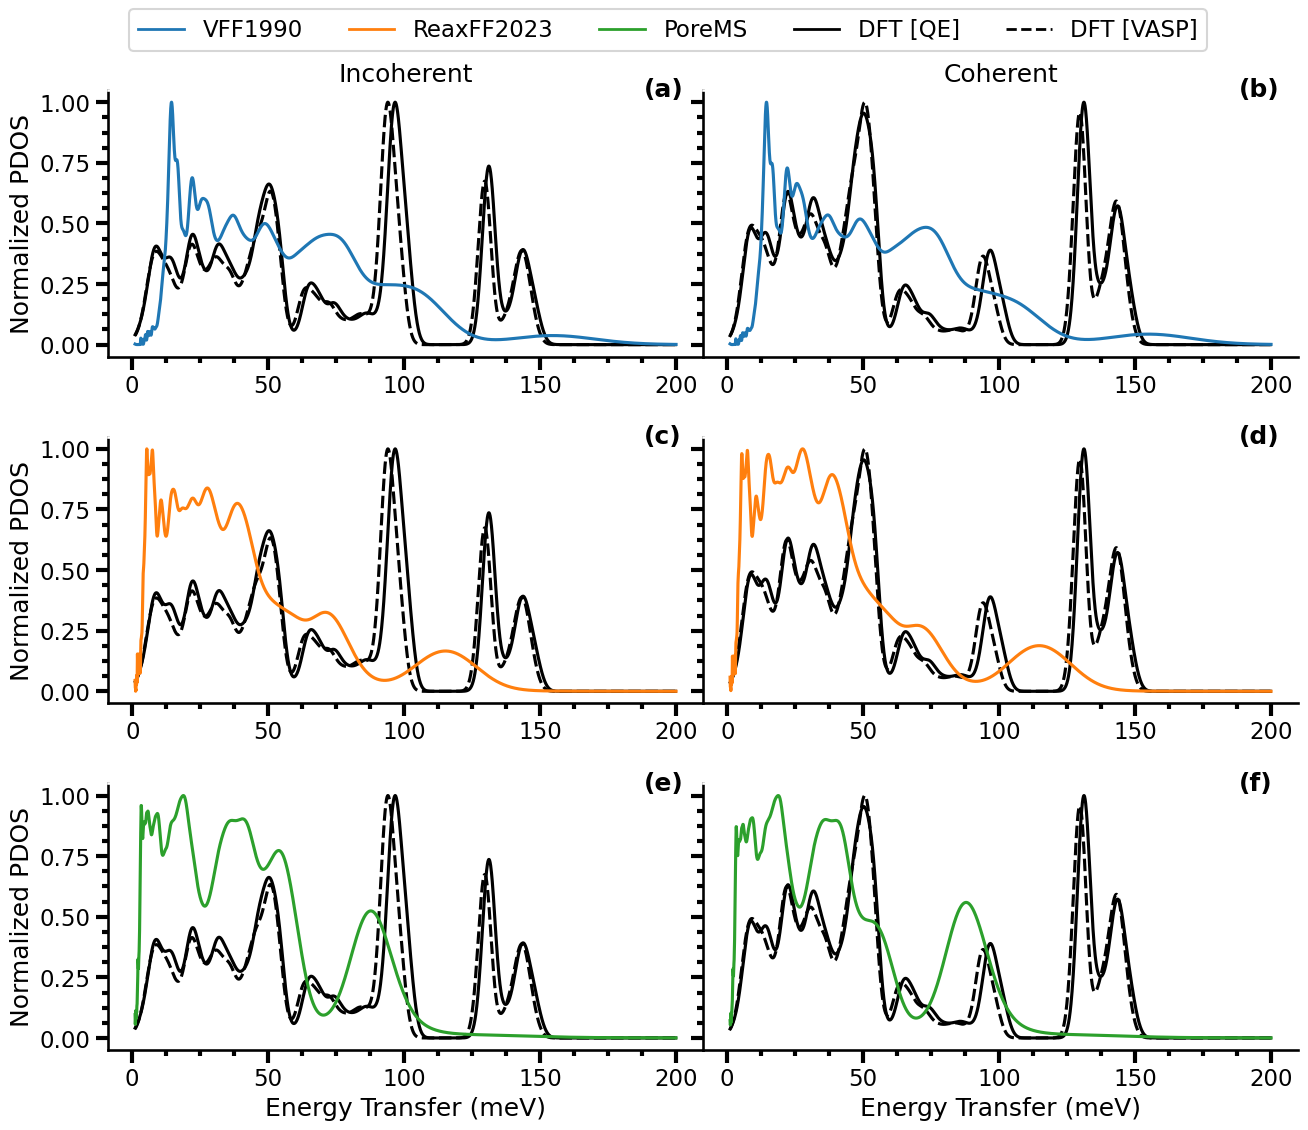

In [9]:
fig, axs = plt.subplots(ncols=2,nrows=3,figsize=(7*2,4*3))
sns.set_context("talk")
palette=sns.color_palette("tab10")

labx=0.9
laby=0.975
emin,emax=1,200
index=["(%s)"%x for x in list("abcdef")]

force_fields=df_dos_md["Force Field"].unique()
for i, weight in enumerate(["Incoherent","Coherent"]):
    for j,force_field in enumerate(force_fields):
        ax=axs[j,i]
        ax.text(labx, laby, index[2*j+i],weight='bold' ,transform=ax.transAxes)
        sns.lineplot(data=df_dos_dft.query(" %f < `Energy Transfer (meV)` and `Energy Transfer (meV)` < %f and Weight== '%s'"%(emin,emax,weight))
                    ,y="Max Normalized Count"
                    ,x='Energy Transfer (meV)'
                    ,ax=ax
                   ,color="black"
                ,style="Software"
                ,legend=False
               )

        sns.lineplot(data=df_dos_md.query(" %f < `Energy Transfer (meV)` and `Energy Transfer (meV)` < %f and Weight== '%s' and `S(E)` > 0 and `Temperature (K)` == 300 and `Force Field` == '%s'"%(emin,emax,weight,force_field))
                    ,y="Max Normalized Count"
                    ,x='Energy Transfer (meV)'
                    ,ax=ax
                   ,color=palette[j]
               )


        ax.spines['bottom'].set_color('0')
        ax.spines['top'].set_color('1')
        ax.spines['right'].set_color('1')
        ax.spines['left'].set_color('0')
        ax.tick_params(direction='out', width=3, bottom=True, left=True)
        ax.grid(False)
        ax.set_ylabel("Normalized PDOS")
        ax.xaxis.set_minor_locator(AutoMinorLocator(4))
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))
        ax.tick_params(which='minor', length=4, width=3)

        if i > 0:
            ax.set_ylabel("")
            ax.set_yticklabels([])
        if j < len(force_fields)-1:
            ax.set_xlabel("")
            
        if j == 0:
            ax.set_title(weight,y=1)
            
custom_lines = [Line2D([0], [0], color=palette[0], lw=2)
                ,Line2D([0], [0], color=palette[1], lw=2)
                ,Line2D([0], [0], color=palette[2], lw=2)
                ,Line2D([0], [0], color="black", lw=2)
                ,Line2D([0], [0], color="black", lw=2,ls="dashed")
               ]
ax.legend(custom_lines,list(force_fields)+["DFT [QE]","DFT [VASP]"])
sns.move_legend(ax,'center',bbox_to_anchor=(0.5,0.95),ncol=6,bbox_transform=fig.transFigure)


            
# set the spacing between subplots
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.95, 
                    top=0.9, 
                    wspace=0., 
                    hspace=0.3
                   )

plt.savefig("../figures/fig3.pdf", pad_inches=0.2,bbox_inches="tight")